## Terceira etapa

Em terceira_etapa.ipynb, utilizaremos dos registros que filtramos (ou não) em segunda_etapa.ipynb, e faremos a filtragem dos estados federativos do(s) país(es) que nos serão úteis. Essa etapa, assim como a anterior, também é necessária para o foco em uma região de estudo específica.

Seguindo a mesma convenção da etapa anterior, o nome do novo campo será stateprovince_att, pois o campo original é stateprovince.

Caso não deseje realizar essa filtragem, siga utilizando o campo stateprovince ao invés de stateprovince_att nas próximas filtragens.

In [ ]:
from bibliotecas import *

specieslink, db_config = configurar()

In [3]:
conn = mysql_conn.connect(**db_config)
cursor = conn.cursor()

requisito = "country_att" # < troque pelo nome da tabela que você utilizou anteriormente para armazenar o país filtrado
                          # mas recomendo manter a convenção do original_att para evitar confusões
coluna = "stateprovince"
table = "registros_biodiversidade"

sql = f"""SELECT {coluna} FROM {table} WHERE {coluna} IS NOT NULL AND {requisito} IS NOT NULL GROUP BY {coluna}"""

cursor.execute(sql)
resultados = cursor.fetchall()

for resultado in resultados:
    print(resultado[0])

cursor.close()
conn.close()  

Rio Grande do Norte
Paraíba
Ceará
Pernambuco
Mato Grosso
Goiás
Santa Catarina
Minas Gerais
Rio Grande do Sul
Paraná
Maranhão
São Paulo
Bahia
Piauí
Distrito Federal
Alagoas
Amapá
Pará
Espírito Santo
MG
ES
RS
SC
RJ
Rio de Janeiro
BA
PR
MS
Tocantins
Mato Grosso do Sul
Sergipe
MaranhÃ£o
Pernanbuco
MA
PI
SP
Amazonas
ESPÍRITO SANTO, ES
MINAS GERAIS, MG
BAHIA, BA
Acre
Rondônia
Roraima
PA
MT
PE
CearÃ¡
ParaÃ­ba
ParanÃ¡
SÃ£o Paulo
CE
GO
Brasília
Paraná 
Rio Branco
Alegrete
Matogroso do Sul
DF
AC
TO
PB
RO
Fernando de Noronha
AL
Estado Não Informado!
Unknown
Sairé


Novamente, a filtragem dos valores que você busca deverá ser feita manualmente, e preenchida no pipeline. No meu caso, separarei pelos estados brasileiros e unificarei em um único nome. Vou utilizar de mapeamento para atualizar os valores - caso o seu resultado seja diferente do meu, o que muito provavelmente será, atualize o mapeamento da seguinte forma:

STATE_MAP = {
    "Nome que quero manter": [
        "Variação de nome 1",
        "Variação de nome 2",
    ],
    (...)
}

In [4]:
STATE_MAP = {
    "Rio de Janeiro": [
        "Rio de Janeiro",
        "RJ",
    ],
    "Minas Gerais": [
        "Minas Gerais",
        "MG",
        "MINAS GERAIS, MG",
    ],
    "São Paulo": [
        "SP",
        "Sao Paulo",
        "São Paulo",
        "SÃ£o Paulo",
    ],
    "Santa Catarina": [
        "Santa Catarina",
        "SC",
    ],
    "Bahia": [
        "Bahia",
        "BA",
        "BAHIA, BA",
    ],
    "Goiás": [
        "Goias",
        "GO",
    ],
    "Mato Grosso": [
        "Mato Grosso",
        "MT",
    ],
    "Ceará": [
        "Ceará",
        "CearÃ¡",
        "CE",
    ],
    "Piaui": [
        "Piaui",
        "PI",
    ],
    "Maranhão": [
        "Maranhão",
        "MA",
       "MaranhÃ£o" ,
    ],
    "Amapá": [
        "Amapá",
    ],
    "Alagoas": [
        "Alagoas",
        "AL",
    ],
    "Pernambuco": [
        "Pernambuco",
        "PE",
        "Fernando de Noronha",
        "Pernanbuco",
        "Sairé",
    ],
    "Rio Grande do Norte": [
        "Rio Grande do Norte",
    ],
    "Sergipe": [
        "Sergipe",
    ],
    "Paraíba": [
        "Paraíba",
        "ParaÃ­ba",
        "PB",
    ],
    "Espírito Santo": [
        "Espírito Santo",
        "ES",
        "ESPÍRITO SANTO, ES",
    ],
    "Pará": [
        "Pará",
        "PA",
    ],
    "Acre": [
        "Acre",
        "Rio Branco",
        "AC",
    ],
    "Paraná": [
        "Parana",
        "Paraná",
        "ParanÃ¡",
        "PR",
    ],
    "Rio Grande do Sul": [
        "Rio Grande do Sul",
        "RS",
        "Alegrete",
    ],
    "Rondônia": [
        "Rondônia",
        "RO",
    ],
    "Distrito Federal": [
        "Distrito Federal",
        "DF",
        "Brasília",
    ],
    "Roraima": [
        "Roraima",
    ],
    "Amazonas": [
        "Amazonas",
    ],
    "Tocantins": [
        "Tocantins",
        "TO",
    ],
    "Mato Grosso do Sul": [
        "Mato Grosso do Sul",
        "MS",
        "Matogroso do Sul",
    ],
}


In [17]:
def filtragem(campo_input, update_input, filters_input, table):
    if not campo_input:
        print("por favor insira um campo")
        return
    
    conn = mysql_conn.connect(**db_config)
    cursor = conn.cursor()

    try:
        sql = f"ALTER TABLE {table} ADD COLUMN {campo_input} TEXT"

        cursor.execute(sql)
        conn.commit()

        print(f"campo '{campo_input}' criado com sucesso na tabela '{table}'")

        cursor.close()
        conn.close()  
    except Exception as e:
        print(f"campo '{campo_input}' já existe ou erro ao criar: {e}")
        
    filters = {}
    if '=' not in filters_input:
        print("filtro mal formatado: use campo=valor1,valor2,...")
        return

    key, value = filters_input.split('=', 1)
    values = [v.strip() for v in value.split(',') if v.strip()]
    filters[key.strip()] = values

    update_values = {}
    if '=' not in update_input: # não está formatado
        print(f"valor de atualização mal formatado: {item} - use chave=valor")
        return
    else:
        key, value = update_input.split('=', 1)
        update_values[key.strip()] = value.strip()

    filter_field, filter_values = next(iter(filters.items()))
    update_field, update_value = next(iter(update_values.items()))
    for valor in filter_values:
        specieslink.update_records(filters={filter_field: valor}, update_values={update_field: update_value}, db_config=db_config, table=table)

In [18]:
campo_input = input("informe o nome que voce deseja que o novo campo tenha (não crie o campo manualmente quando executando pelo pipeline!)").strip()
table = "registros_biodiversidade"

for estado_padrao, variantes in STATE_MAP.items():
    for variante in variantes:
        update_input = f"{campo_input}={estado_padrao}"
        filters_input = f"stateprovince={variante}"

        print(f"executando specieslink.update_records(filters={filters_input}, update_values={update_input}, table={table})...\n")

        filtragem(campo_input=campo_input,update_input=update_input,filters_input=filters_input,table=table)


executando specieslink.update_records(filters=stateprovince=Rio de Janeiro, update_values=stateprovince_att=Rio de Janeiro, table=registros_biodiversidade)...

campo 'stateprovince_att' já existe ou erro ao criar: 1060 (42S21): Duplicate column name 'stateprovince_att'
conexão bem-sucedida
query gerada para UPDATE: 
                UPDATE teste_pipeline.registros_biodiversidade
                SET stateprovince_att = %s
                WHERE stateprovince = %s
            
valores para UPDATE: ['Rio de Janeiro', 'Rio de Janeiro']
916 registro(s) atualizado(s).
conexão encerrada
executando specieslink.update_records(filters=stateprovince=RJ, update_values=stateprovince_att=Rio de Janeiro, table=registros_biodiversidade)...

campo 'stateprovince_att' já existe ou erro ao criar: 1060 (42S21): Duplicate column name 'stateprovince_att'
conexão bem-sucedida
query gerada para UPDATE: 
                UPDATE teste_pipeline.registros_biodiversidade
                SET stateprovince_att = %s
   

In [19]:
conn = mysql_conn.connect(**db_config)
cursor = conn.cursor()

sql = """
SELECT
    COUNT(*) AS total_registros,
    SUM(country_att IS NOT NULL) AS com_country,
    SUM(country_att IS NOT NULL AND stateprovince_att IS NOT NULL) AS com_country_e_state
FROM registros_biodiversidade
"""

cursor.execute(sql)
total_registros, registros_country, registros_country_state = cursor.fetchone()

cursor.close()
conn.close()

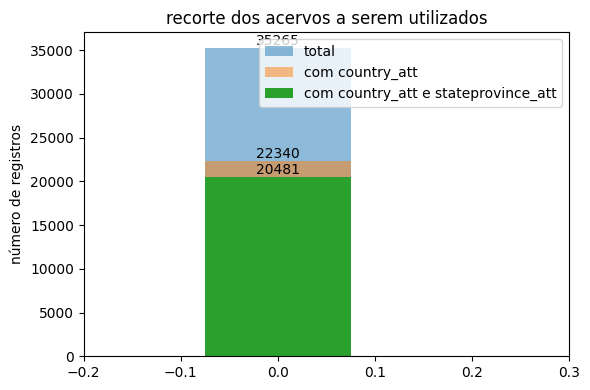

In [20]:
plt.figure(figsize=(6, 4))

x = [0]

plt.bar(
    x,
    [total_registros],
    alpha=0.5,
    width=0.15,
    label='total'
)

plt.bar(
    x,
    [registros_country],
    alpha=0.5,
    width=0.15,
    label='com country_att'
)

plt.bar(
    x,
    [registros_country_state],
    width=0.15,
    label='com country_att e stateprovince_att'
)

plt.xlim(-0.2, 0.3)
plt.ylabel('número de registros')
plt.title('recorte dos acervos a serem utilizados')
plt.legend()

plt.text(0, total_registros, str(total_registros), ha='center', va='bottom')
plt.text(0, registros_country, str(registros_country), ha='center', va='bottom')
plt.text(0, registros_country_state, str(registros_country_state), ha='center', va='bottom')

plt.tight_layout()
plt.show()